In [1]:
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy import stats

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

In [2]:
df = pd.read_csv('/content/WineQT.csv')

In [3]:
df.shape

(1143, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [5]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [6]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [7]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

In [8]:
df = df[[
  'fixed acidity', 'volatile acidity', 'citric acid', #'residual sugar',
  'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
  'pH', 'sulphates', 'alcohol', 'quality', #'Id'
]]

In [9]:
df.loc[df.duplicated()]

,fixed acidity,volatile acidity,citric acid,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.4,0.700,0.00,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
46,7.2,0.725,0.05,0.086,4.0,11.0,0.99620,3.41,0.39,10.9,5
64,8.6,0.490,0.28,0.110,20.0,136.0,0.99720,2.93,1.95,9.9,6
65,7.7,0.490,0.26,0.062,9.0,31.0,0.99660,3.39,0.64,9.6,5
71,8.1,0.545,0.18,0.080,13.0,35.0,0.99720,3.30,0.59,9.0,6
...,...,...,...,...,...,...,...,...,...,...,...
1076,7.5,0.380,0.57,0.106,5.0,12.0,0.99605,3.36,0.55,11.4,6
1113,7.8,0.600,0.26,0.080,31.0,131.0,0.99622,3.21,0.52,9.9,5
1114,7.8,0.600,0.26,0.080,31.0,131.0,0.99622,3.21,0.52,9.9,5
1116,7.2,0.695,0.13,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5


In [10]:
df = df.drop_duplicates(keep='first')

In [11]:
df.shape

(1018, 11)

In [12]:
df = df.rename(columns={
'fixed acidity':'fixed_acidity',
'volatile acidity':'volatile_acidity',
'citric acid':'citric_acid',
'free sulfur dioxide':'free_sulfur_dioxide',
'total sulfur dioxide':'total_sulfur_dioxide',
})

In [13]:
missing = df.isnull().sum()
missing

,0
fixed_acidity,0
volatile_acidity,0
citric_acid,0
chlorides,0
free_sulfur_dioxide,0
total_sulfur_dioxide,0
density,0
pH,0
sulphates,0
alcohol,0


In [14]:
df.dtypes

,0
fixed_acidity,float64
volatile_acidity,float64
citric_acid,float64
chlorides,float64
free_sulfur_dioxide,float64
total_sulfur_dioxide,float64
density,float64
pH,float64
sulphates,float64
alcohol,float64


In [15]:
df.head()

,fixed_acidity,volatile_acidity,citric_acid,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
5,7.4,0.66,0.00,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


- Como o total de ácido sulfúrico impacta no pH do vinho?

In [16]:
df[['pH','total_sulfur_dioxide']].corr()

,pH,total_sulfur_dioxide
pH,1.000000,-0.071037
total_sulfur_dioxide,-0.071037,1.000000


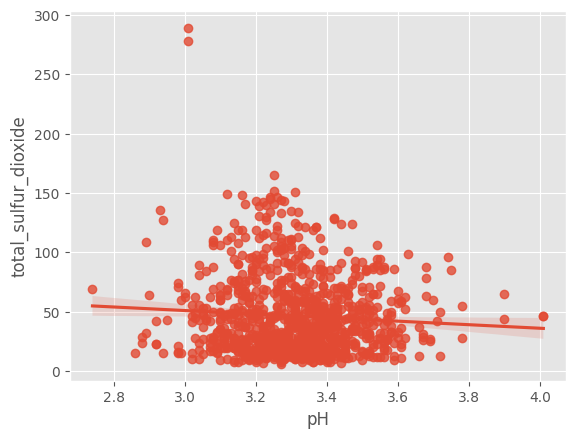

In [38]:
sns.regplot(x='pH', y='total_sulfur_dioxide', data=df)
plt.show()

In [18]:
r, p = stats.pearsonr(df['total_sulfur_dioxide'], df['pH'])
print(f'r:{np.round(r,2)}')
print(f'p:{np.round(p,4)}')

r:-0.07
p:0.0234


Nota-se que a correlação entre **TOTAL DE ÁCIDO SULFÚRICO** e **PH** é negativa fraca mas moderadamente significativa, ou seja, embora as variáveis não se correlacionem muito bem entre si, são estatisiticamente significantes.

- Qual a relação entre acidez fixa, volátil e cítrica e o pH do vinho?

In [19]:
df[['fixed_acidity','volatile_acidity','citric_acid', 'pH']].corr()

,fixed_acidity,volatile_acidity,citric_acid,pH
fixed_acidity,1.000000,-0.236894,0.668178,-0.692597
volatile_acidity,-0.236894,1.000000,-0.542459,0.226348
citric_acid,0.668178,-0.542459,1.000000,-0.553370
pH,-0.692597,0.226348,-0.553370,1.000000


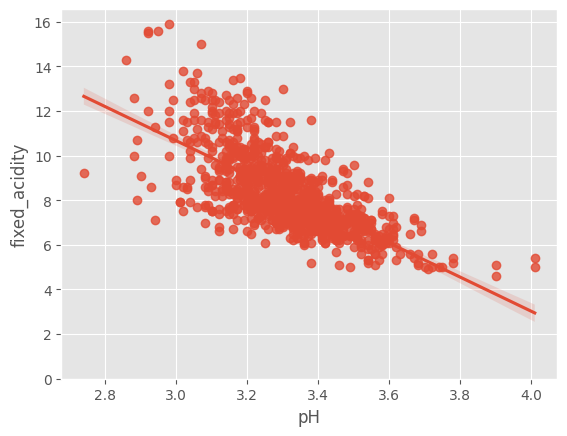

In [20]:
sns.regplot(x='pH', y='fixed_acidity', data=df)
plt.ylim(0,)
plt.show()

In [21]:
r, p = stats.pearsonr(df['fixed_acidity'], df['pH'])
print(f'r:{np.round(r,2)}')
print(f'p:{np.round(p,4)}')

r:-0.69
p:0.0


Para acidez fixa: Possui uma correlação negativa e significante, indicando que uma acidez baixa resulta em um pH alto, na maior parte das vezes

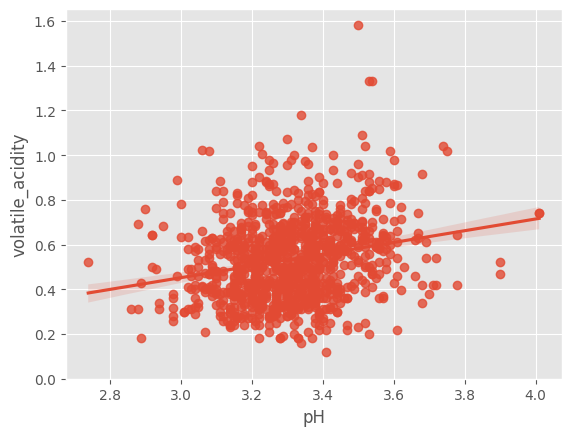

In [22]:
sns.regplot(x='pH',y='volatile_acidity',data=df)
plt.ylim(0,)
plt.show()

In [23]:
r, p = stats.pearsonr(df['volatile_acidity'], df['pH'])
print(f'r:{np.round(r,2)}')
print(f'p:{np.round(p,4)}')

r:0.23
p:0.0


Para acidez volátil: Possui uma correlação positiva e significante, indicando que a medida em que o pH cresce, a acidez volátil também cresce

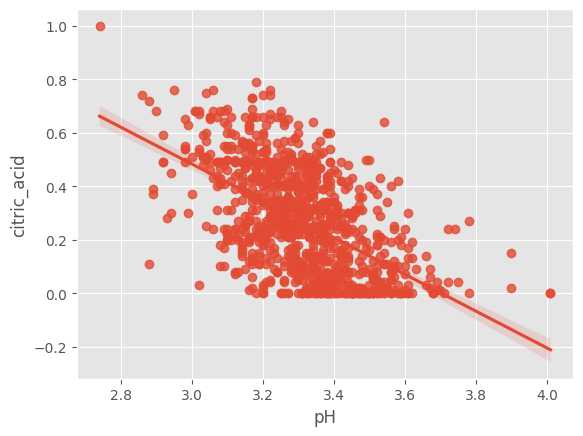

In [24]:
sns.regplot(x='pH',y='citric_acid',data=df)
plt.show()

In [25]:
r, p = stats.pearsonr(df['citric_acid'], df['pH'])
print(f'r:{np.round(r,2)}')
print(f'p:{np.round(p,4)}')

r:-0.55
p:0.0


Para acidez cítrica: Possui uma correlação negativa e significante, indicando que uma acidez cítrica baixa resulta em um pH alto, na maior parte das vezes

Com isso, baseado nos dados, conclui-se que quanto menor for a acidez cítrica e fixa maior será o pH e quanto maior for a acidez volátil, maior será o pH.

- Como o pH se relaciona com a qualidade do vinho?

In [26]:
df[['pH', 'quality']].corr()

,pH,quality
pH,1.000000,-0.057592
quality,-0.057592,1.000000


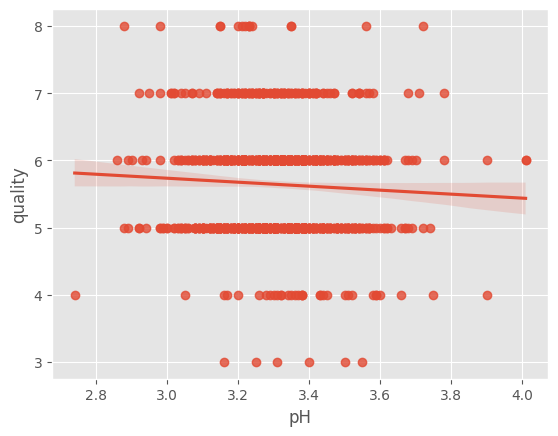

In [27]:
sns.regplot(x='pH',y='quality',data=df)
plt.show()

In [28]:
r, p = stats.pearsonr(df['quality'], df['pH'])
print(f'r:{np.round(r,2)}')
print(f'p:{np.round(p,4)}')

r:-0.06
p:0.0662


Como mostram os dados, qualidade e pH demonstram uma correlação negativa fraca e pouco significativa, indicando que uma variável não interfere na outra

- Qual a relação entre qualidade e densidade do vinho?

In [29]:
df[['quality', 'density']].corr()

,quality,density
quality,1.000000,-0.185187
density,-0.185187,1.000000


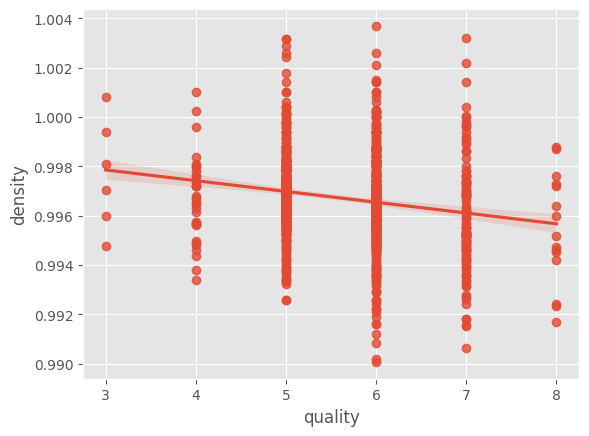

In [30]:
sns.regplot(x='quality',y='density',data=df)
plt.show()

In [31]:
r, p = stats.pearsonr(df['density'], df['quality'])
print(f'r:{np.round(r,2)}')
print(f'p:{np.round(p,4)}')

r:-0.19
p:0.0


Como mostram os dados, qualidade e densidade do vinho possuem uma correlação negativa fraca porém significativa.

- Qual a relação entre teor alcoolico e acidez volátil?

In [32]:
df[['volatile_acidity', 'alcohol']].corr()

,volatile_acidity,alcohol
volatile_acidity,1.000000,-0.207419
alcohol,-0.207419,1.000000


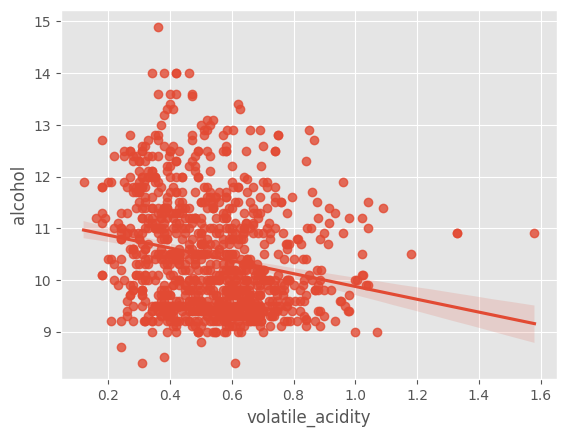

In [33]:
sns.regplot(x='volatile_acidity',y='alcohol',data=df)
plt.show()

In [34]:
r, p = stats.pearsonr(df['volatile_acidity'], df['alcohol'])
print(f'r:{np.round(r,2)}')
print(f'p:{np.round(p,4)}')

r:-0.21
p:0.0


Como pode ser visto no gráfico, teor alcoólico e acidez volátil tem uma correlação negativa fraca porém muito significativa. Isso significa que uma pode influenciar na outra

- Qual a relação entre qualidade e teor alcoolico?

In [35]:
df[['quality','alcohol']].corr()

,quality,alcohol
quality,1.000000,0.485953
alcohol,0.485953,1.000000


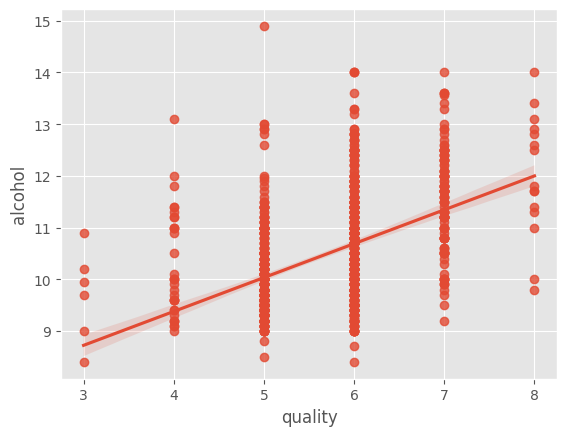

In [36]:
sns.regplot(x='quality',y='alcohol',data=df)
plt.show()

In [37]:
r, p = stats.pearsonr(df['quality'], df['alcohol'])
print(f'r:{np.round(r,2)}')
print(f'p:{np.round(p,4)}')

r:0.49
p:0.0


Como os dados mostram, teor alcoólico e qualidade do vinho tem uma correlação positiva moderada e altamente significativa, indicando que uma influencia na outra

---

#Concluindo o Dataset

***O que define a qualidade de um vinho?***

Das variáveis analisadas, o **teor alcoólico** foi a que apresentou
correlação mais forte com a **qualidade** (r = 0.48, p < 0.001),
sendo o melhor preditor individual identificado nesta análise.

O **pH** e a **densidade** mostraram correlações significativas
mas fracas, sugerindo influência pequena sobre a **qualidade**.

Para uma predição mais robusta da qualidade, um modelo de
regressão ou classificação considerando múltiplas variáveis
simultaneamente seria o próximo passo natural.